In [22]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

conn = sqlite3.connect("../data/vayu_clean.db")
df = pd.read_sql("SELECT * FROM features", conn, parse_dates=["timestamp"])
conn.close()

print(df.shape)
df.info()
df.tail()

(129180, 27)
<class 'pandas.DataFrame'>
RangeIndex: 129180 entries, 0 to 129179
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id                 129180 non-null  int64         
 1   city               129180 non-null  str           
 2   latitude           129180 non-null  float64       
 3   longitude          129180 non-null  float64       
 4   aqi                129180 non-null  int64         
 5   pm25               129180 non-null  float64       
 6   pm10               129180 non-null  float64       
 7   no2                129180 non-null  float64       
 8   o3                 129180 non-null  float64       
 9   timestamp          129180 non-null  datetime64[us]
 10  fetched_at         129180 non-null  str           
 11  temperature_c      129180 non-null  float64       
 12  humidity_pct       129180 non-null  float64       
 13  wind_speed_ms      106860 non-null  float6

,id,city,latitude,longitude,aqi,pm25,pm10,no2,o3,timestamp,...,day_of_week,month,is_weekend,aqi_lag_1h,aqi_lag_3h,aqi_lag_24h,aqi_roll_6h,aqi_roll_24h,next_aqi,next_aqi_category
129175,129979,Shillong,25.5788,91.8933,1,7.81,9.13,6.12,36.27,2026-07-06 19:00:00,...,0,7,0,1.0,1.0,1.0,1.0,1.0,2.0,Fair
129176,129980,Shillong,25.5788,91.8933,1,7.14,8.13,6.15,34.61,2026-07-06 20:00:00,...,0,7,0,1.0,1.0,1.0,1.0,1.0,2.0,Fair
129177,129981,Shillong,25.5788,91.8933,1,6.37,7.23,6.06,33.10,2026-07-06 21:00:00,...,0,7,0,1.0,1.0,1.0,1.0,1.0,1.0,Good
129178,129982,Shillong,25.5788,91.8933,1,5.63,6.42,5.91,31.69,2026-07-06 22:00:00,...,0,7,0,1.0,1.0,1.0,1.0,1.0,1.0,Good
129179,129983,Shillong,25.5788,91.8933,1,5.04,5.81,5.72,30.88,2026-07-06 23:00:00,...,0,7,0,1.0,1.0,1.0,1.0,1.0,1.0,Good


In [2]:
df.describe()[["aqi", "pm25", "pm10", "no2", "o3", "temperature_c", "wind_speed_ms"]]

,aqi,pm25,pm10,no2,o3,temperature_c,wind_speed_ms
count,129180.000000,129180.000000,129180.000000,129180.000000,129180.000000,129180.000000,106860.000000
mean,2.969577,51.116358,64.085736,6.302586,71.001371,25.273474,2.356220
min,1.000000,0.000000,0.000000,0.030000,0.000000,3.200000,0.000000
25%,2.000000,10.517500,15.680000,1.950000,35.750000,21.700000,1.410000
50%,3.000000,30.260000,44.455000,4.710000,60.640000,25.900000,2.200000
75%,4.000000,69.450000,89.302500,8.860000,98.390000,29.200000,3.100000
max,5.000000,675.850000,684.660000,58.830000,280.930000,44.100000,10.120000
std,1.446348,60.431110,66.335691,5.860488,44.610000,6.062562,1.282718


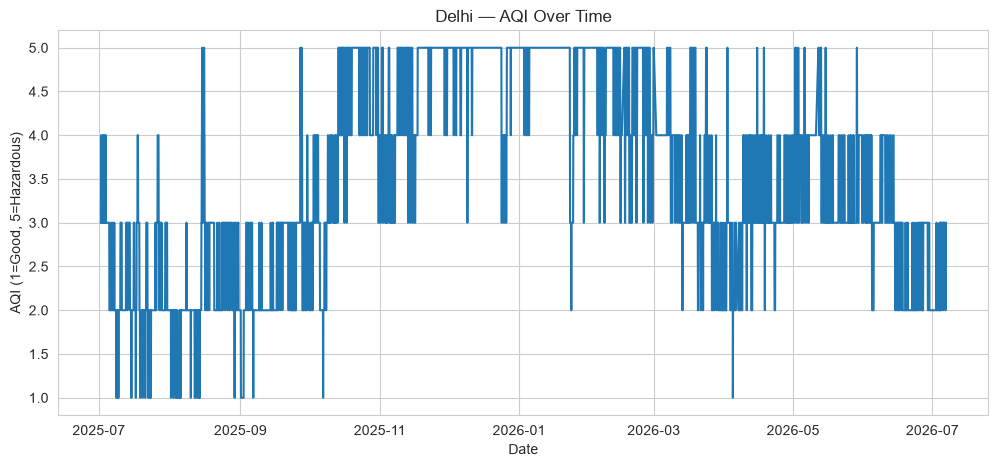

In [3]:
delhi = df[df["city"] == "Delhi"].sort_values("timestamp")

plt.plot(delhi["timestamp"], delhi["aqi"])
plt.title("Delhi — AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI (1=Good, 5=Hazardous)")
plt.show()

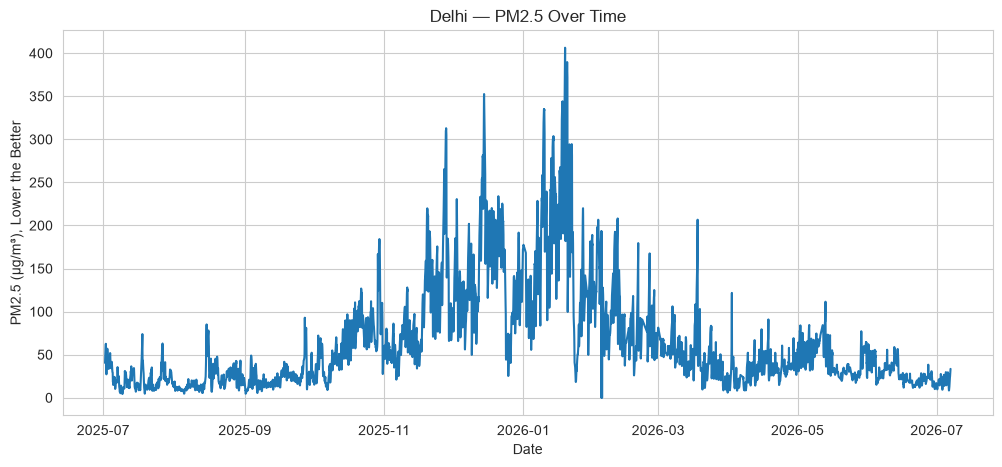

In [4]:
delhi = df[df["city"] == "Delhi"].sort_values("timestamp")

plt.plot(delhi["timestamp"], delhi["pm25"])
plt.title("Delhi — PM2.5 Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³), Lower the Better")
plt.show()

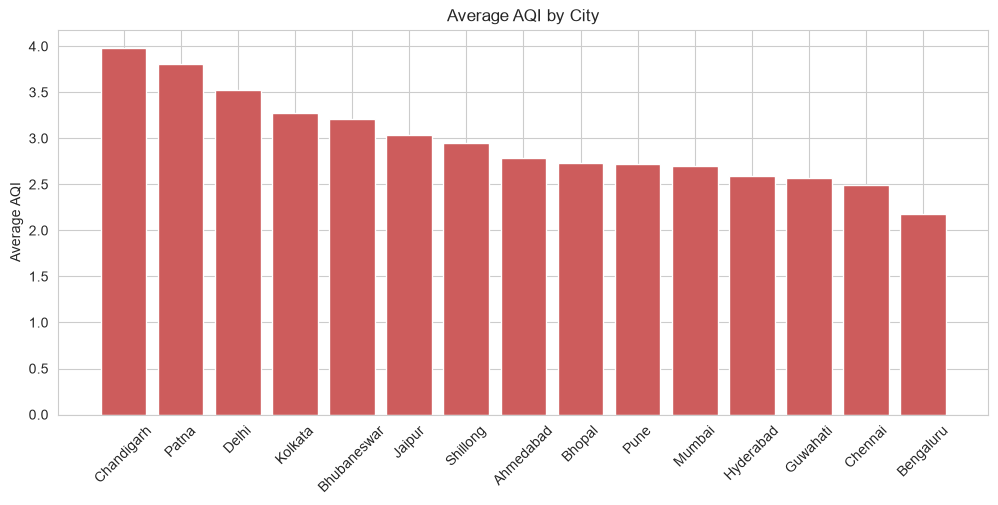

city
Chandigarh     3.981970
Patna          3.803187
Delhi          3.523378
Kolkata        3.271747
Bhubaneswar    3.205769
Jaipur         3.035241
Shillong       2.951862
Ahmedabad      2.790770
Bhopal         2.732116
Pune           2.723340
Mumbai         2.700093
Hyderabad      2.585252
Guwahati       2.567800
Chennai        2.495115
Bengaluru      2.180391
Name: aqi, dtype: float64

In [5]:
city_avg = df.groupby("city")["aqi"].mean().sort_values(ascending=False)

plt.bar(city_avg.index, city_avg.values, color="indianred")
plt.title("Average AQI by City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.show()

city_avg

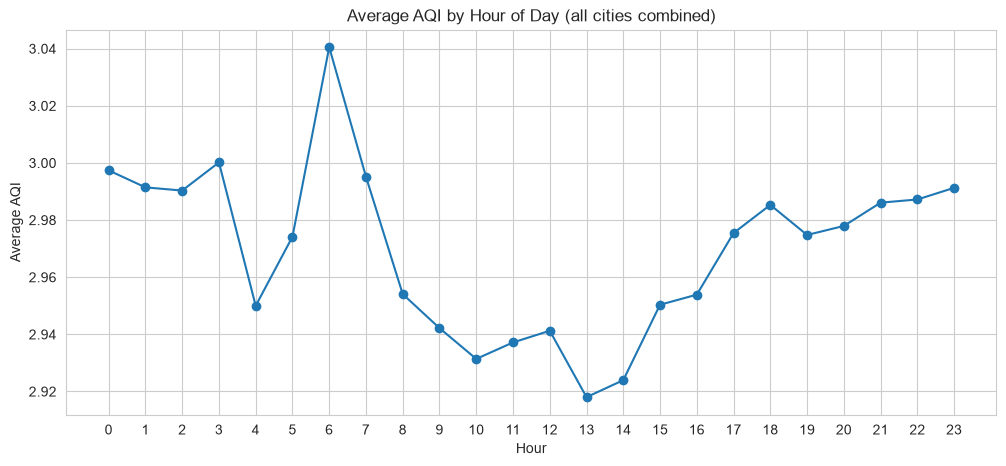

In [6]:
hourly_avg = df.groupby("hour")["aqi"].mean()

plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average AQI by Hour of Day (all cities combined)")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.show()

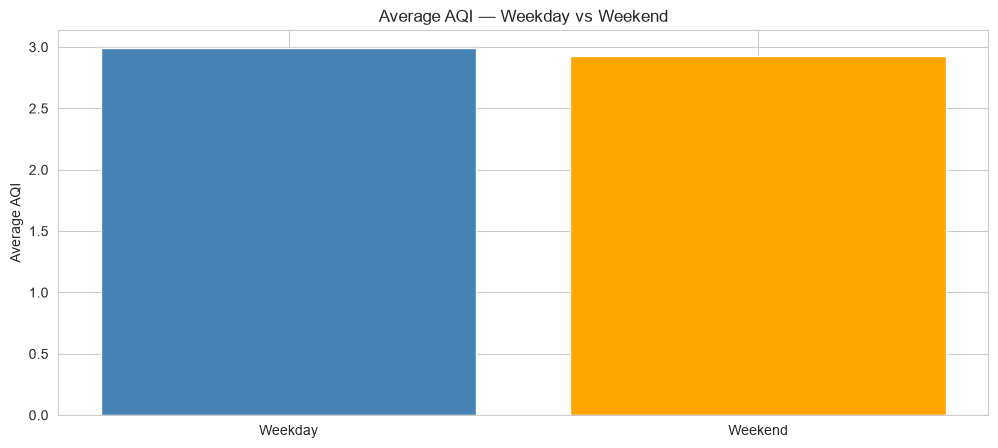

In [7]:
weekend_avg = df.groupby("is_weekend")["aqi"].mean()
weekend_avg.index = ["Weekday", "Weekend"]

plt.bar(weekend_avg.index, weekend_avg.values, color=["steelblue", "orange"])
plt.title("Average AQI — Weekday vs Weekend")
plt.ylabel("Average AQI")
plt.show()

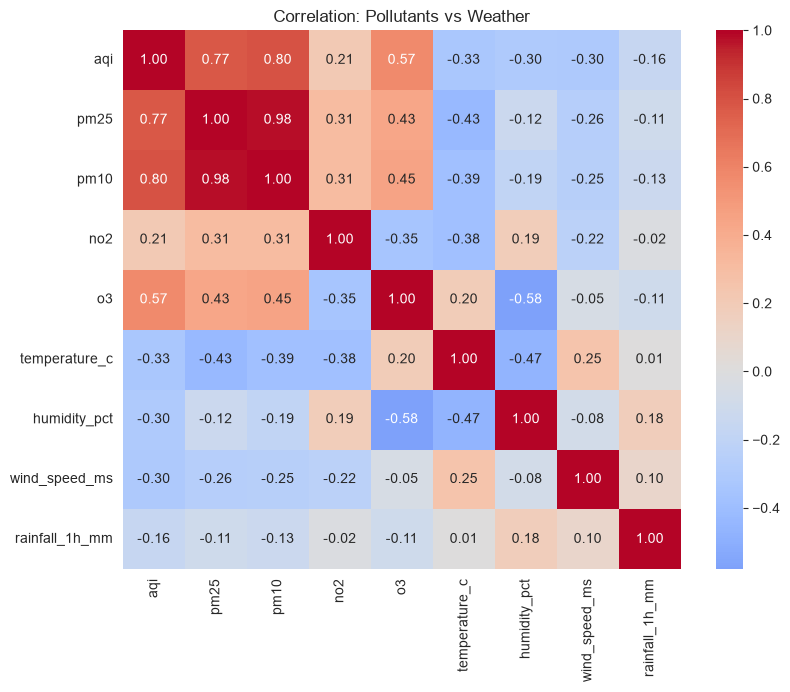

In [8]:
corr_cols = ["aqi", "pm25", "pm10", "no2", "o3",
             "temperature_c", "humidity_pct", "wind_speed_ms", "rainfall_1h_mm"]

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: Pollutants vs Weather")
plt.show()

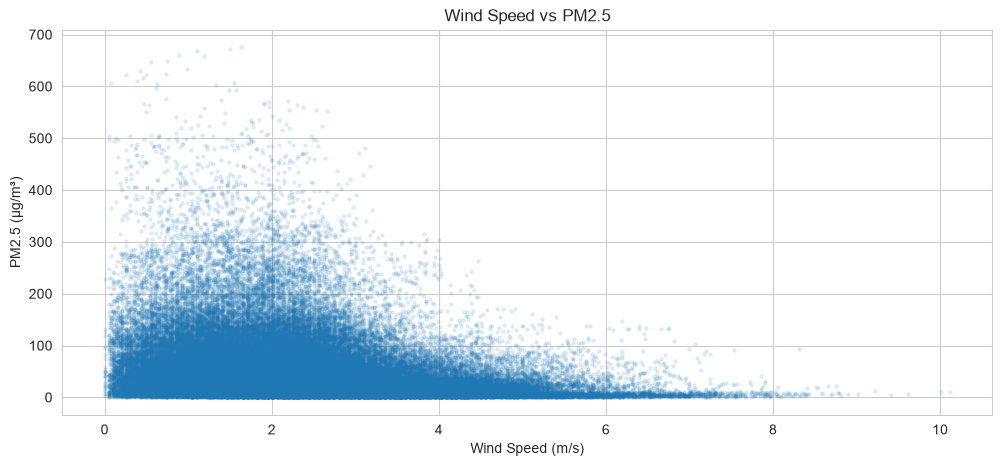

In [9]:
plt.scatter(df["wind_speed_ms"], df["pm25"], alpha=0.1, s=5)
plt.title("Wind Speed vs PM2.5")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

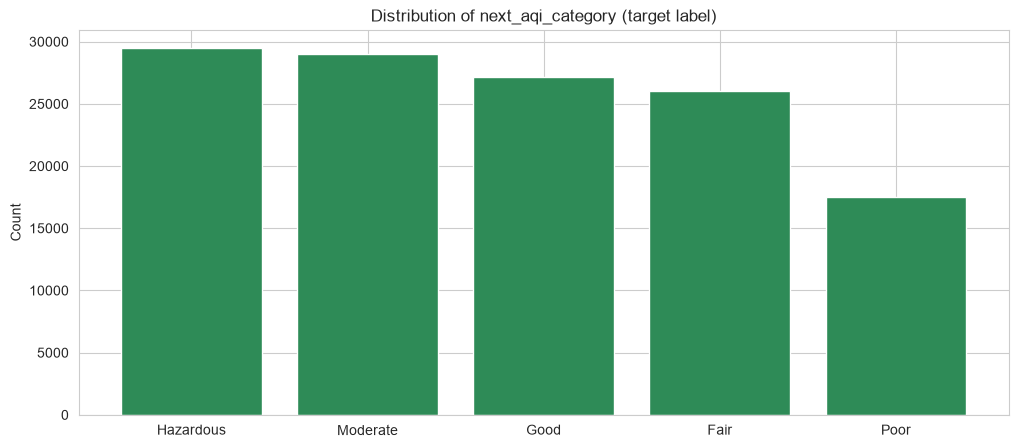

next_aqi_category
Hazardous    29476
Moderate     29030
Good         27167
Fair         25999
Poor         17508
Name: count, dtype: int64

In [10]:
label_counts = df["next_aqi_category"].value_counts()

plt.bar(label_counts.index, label_counts.values, color="seagreen")
plt.title("Distribution of next_aqi_category (target label)")
plt.ylabel("Count")
plt.show()

label_counts

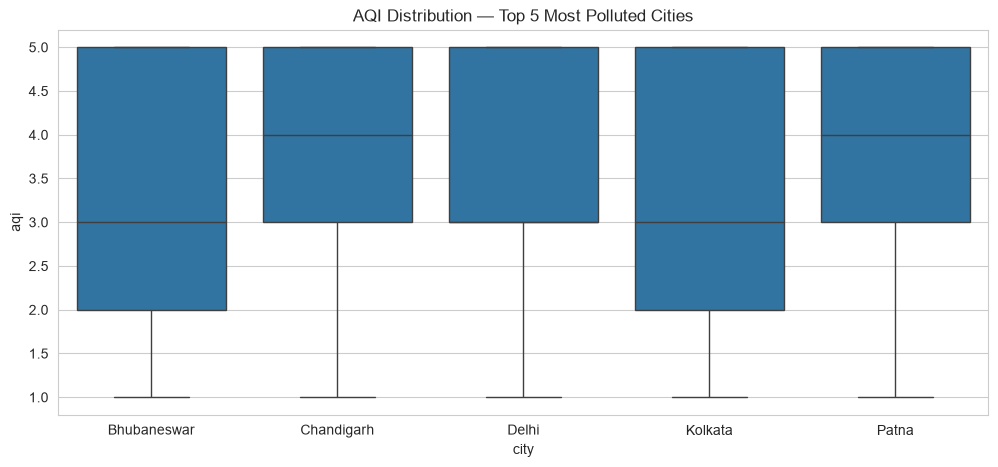

In [11]:
top5 = city_avg.head(5).index.tolist()

sns.boxplot(data=df[df["city"].isin(top5)], x="city", y="aqi")
plt.title("AQI Distribution — Top 5 Most Polluted Cities")
plt.show()

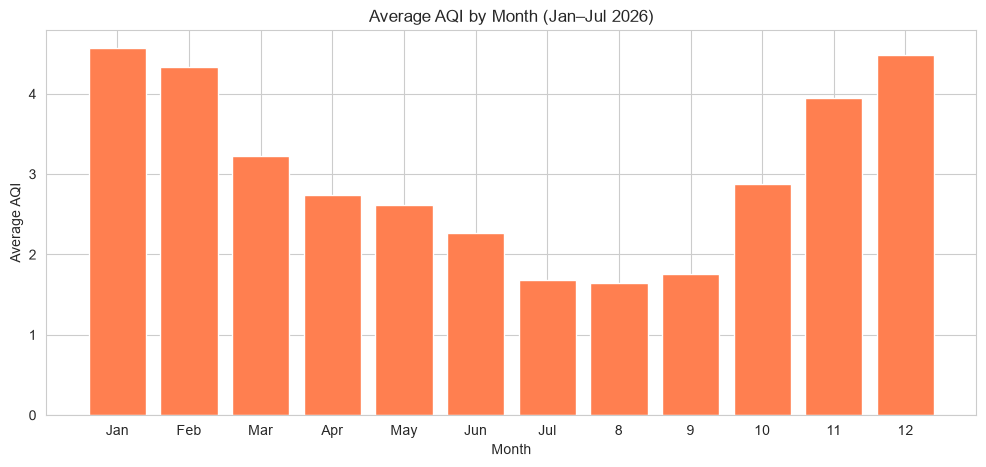

Jan    4.563793
Feb    4.334778
Mar    3.225552
Apr    2.736398
May    2.616923
Jun    2.268265
Jul    1.686599
8      1.645251
9      1.760278
10     2.873297
11     3.942500
12     4.484588
Name: aqi, dtype: float64

In [12]:
monthly_avg = df.groupby("month")["aqi"].mean()

month_names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun", 7:"Jul"}
monthly_avg.index = [month_names.get(m, str(m)) for m in monthly_avg.index]

plt.bar(monthly_avg.index, monthly_avg.values, color="coral")
plt.title("Average AQI by Month (Jan–Jul 2026)")
plt.ylabel("Average AQI")
plt.xlabel("Month")
plt.show()

monthly_avg

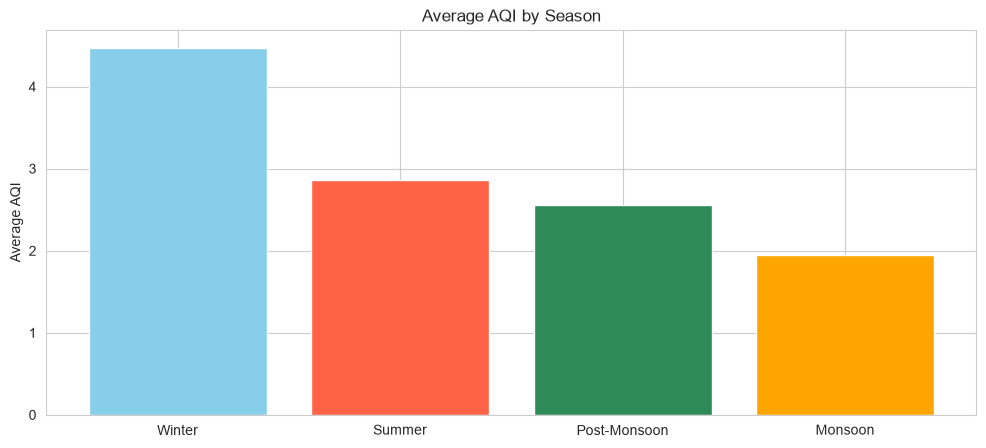

season
Winter          4.467549
Summer          2.862719
Post-Monsoon    2.550478
Monsoon         1.946171
Name: aqi, dtype: float64

In [13]:
def label_season(month):
    if month in [12, 1, 2]:   return "Winter"
    elif month in [3, 4, 5]:  return "Summer"
    elif month in [6, 7]:     return "Monsoon"
    else:                      return "Post-Monsoon"

df["season"] = df["month"].apply(label_season)

season_avg = df.groupby("season")["aqi"].mean().sort_values(ascending=False)

plt.bar(season_avg.index, season_avg.values, 
        color=["skyblue", "tomato", "seagreen", "orange"])
plt.title("Average AQI by Season")
plt.ylabel("Average AQI")
plt.show()

season_avg

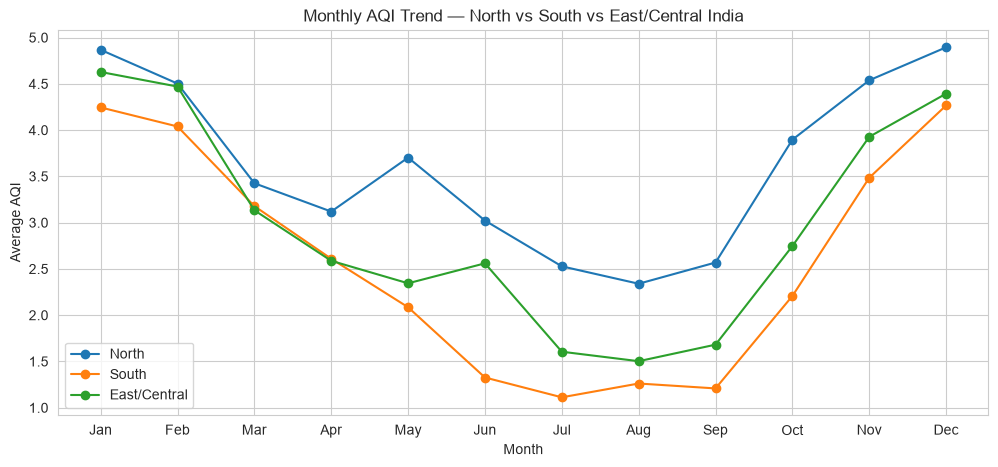

In [14]:
north = ["Delhi", "Patna", "Chandigarh", "Jaipur"]
south = ["Chennai", "Bengaluru", "Hyderabad", "Mumbai", "Pune"]

df["region"] = df["city"].apply(
    lambda x: "North" if x in north else ("South" if x in south else "East/Central")
)

region_monthly = df.groupby(["region", "month"])["aqi"].mean().reset_index()

# Automatically convert month numbers (1–12) to Jan, Feb, ..., Dec
region_monthly["month_name"] = pd.to_datetime(
    region_monthly["month"], format="%m"
).dt.strftime("%b")

for region in ["North", "South", "East/Central"]:
    subset = region_monthly[region_monthly["region"] == region]
    plt.plot(subset["month_name"], subset["aqi"], marker="o", label=region)

plt.title("Monthly AQI Trend — North vs South vs East/Central India")
plt.ylabel("Average AQI")
plt.xlabel("Month")
plt.legend()
plt.show()

Average AQI during monsoon months (Jun–Sep)  : 1.83
Average AQI during non-monsoon months         : 3.59
Average rainfall during monsoon (mm/hr)       : 0.325
Average rainfall during non-monsoon (mm/hr)   : 0.059


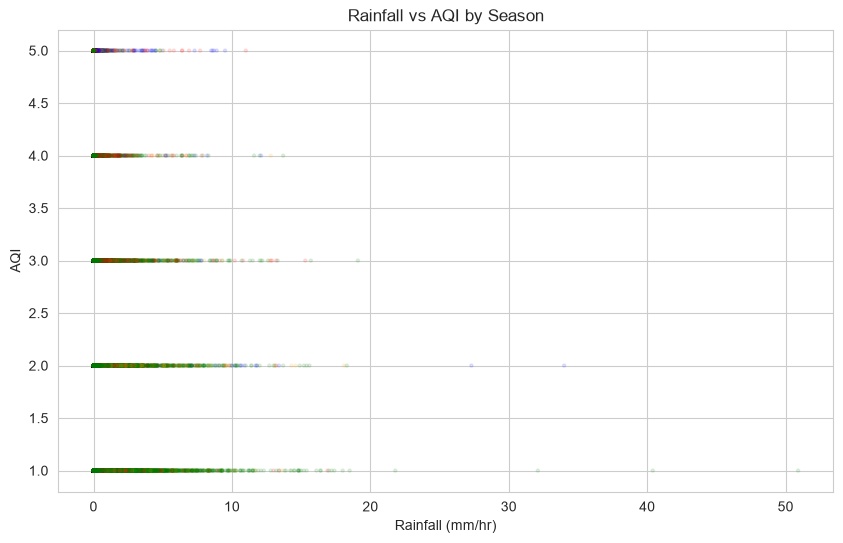

In [15]:
# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

# Add season column
df["season"] = df["month"].apply(get_season)

# Monsoon vs non-monsoon comparison
monsoon_months = df[df["month"].isin([6, 7, 8, 9])]
non_monsoon = df[~df["month"].isin([6, 7, 8, 9])]

print(f"Average AQI during monsoon months (Jun–Sep)  : {monsoon_months['aqi'].mean():.2f}")
print(f"Average AQI during non-monsoon months         : {non_monsoon['aqi'].mean():.2f}")
print(f"Average rainfall during monsoon (mm/hr)       : {monsoon_months['rainfall_1h_mm'].mean():.3f}")
print(f"Average rainfall during non-monsoon (mm/hr)   : {non_monsoon['rainfall_1h_mm'].mean():.3f}")

# Scatter plot: Rainfall vs AQI, colored by season
colors = df["season"].map({
    "Winter": "blue",
    "Summer": "red",
    "Monsoon": "green",
    "Post-Monsoon": "orange"
})

plt.figure(figsize=(10, 6))
plt.scatter(
    df["rainfall_1h_mm"],
    df["aqi"],
    c=colors,
    alpha=0.1,
    s=5
)

plt.title("Rainfall vs AQI by Season")
plt.xlabel("Rainfall (mm/hr)")
plt.ylabel("AQI")
plt.grid(True)
plt.show()

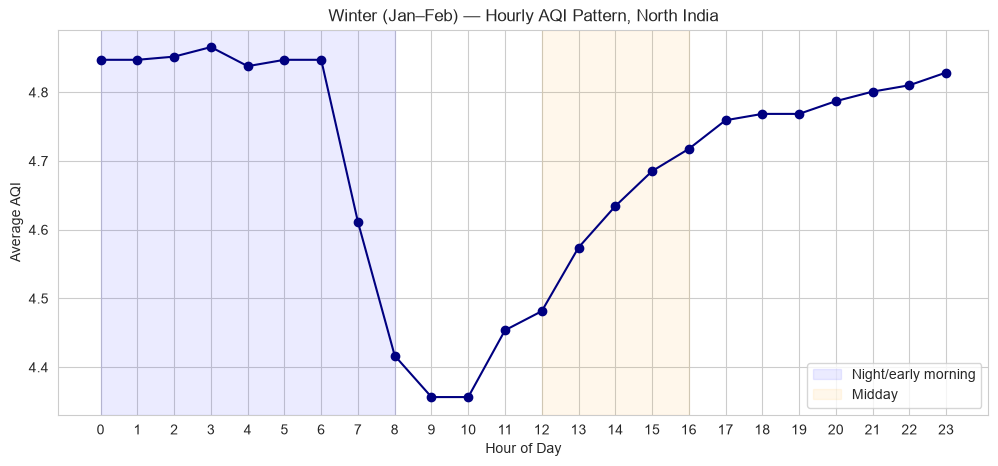

In [16]:
winter_north = df[
    (df["month"].isin([1, 2])) &
    (df["city"].isin(north))
]

winter_hourly = winter_north.groupby("hour")["aqi"].mean()

plt.plot(winter_hourly.index, winter_hourly.values, marker="o", color="navy")
plt.title("Winter (Jan–Feb) — Hourly AQI Pattern, North India")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.axvspan(0, 8, alpha=0.08, color="blue", label="Night/early morning")
plt.axvspan(12, 16, alpha=0.08, color="orange", label="Midday")
plt.legend()
plt.show()

In [17]:
city = "Ahmedabad"

check = df[df["city"] == city].sort_values("timestamp").tail(48)

print(check[["timestamp", "aqi"]])
print(check["aqi"].value_counts())

               timestamp  aqi
8598 2026-07-05 01:00:00    2
8599 2026-07-05 02:00:00    2
8600 2026-07-05 03:00:00    1
8601 2026-07-05 04:00:00    1
8602 2026-07-05 05:00:00    1
8603 2026-07-05 06:00:00    1
8604 2026-07-05 07:00:00    1
8605 2026-07-05 08:00:00    1
8606 2026-07-05 09:00:00    1
8607 2026-07-05 10:00:00    1
8608 2026-07-05 11:00:00    1
8609 2026-07-05 12:00:00    1
8610 2026-07-05 13:00:00    1
8611 2026-07-05 14:00:00    1
8612 2026-07-05 15:00:00    1
8613 2026-07-05 16:00:00    1
8614 2026-07-05 17:00:00    1
8615 2026-07-05 18:00:00    1
8616 2026-07-05 19:00:00    1
8617 2026-07-05 20:00:00    1
8618 2026-07-05 21:00:00    2
8619 2026-07-05 22:00:00    2
8620 2026-07-05 23:00:00    2
8621 2026-07-06 00:00:00    2
8622 2026-07-06 01:00:00    2
8623 2026-07-06 02:00:00    2
8624 2026-07-06 03:00:00    2
8625 2026-07-06 04:00:00    3
8626 2026-07-06 05:00:00    3
8627 2026-07-06 06:00:00    3
8628 2026-07-06 07:00:00    3
8629 2026-07-06 08:00:00    3
8630 2026-

In [18]:
city = "Pune"

check = df[df["city"] == city].sort_values("timestamp").tail(48)

print(check[["timestamp", "aqi"]])
print(check["aqi"].value_counts())

                 timestamp  aqi
120511 2026-07-05 01:00:00    1
120512 2026-07-05 02:00:00    1
120513 2026-07-05 03:00:00    1
120514 2026-07-05 04:00:00    1
120515 2026-07-05 05:00:00    1
120516 2026-07-05 06:00:00    1
120517 2026-07-05 07:00:00    1
120518 2026-07-05 08:00:00    1
120519 2026-07-05 09:00:00    1
120520 2026-07-05 10:00:00    1
120521 2026-07-05 11:00:00    1
120522 2026-07-05 12:00:00    1
120523 2026-07-05 13:00:00    1
120524 2026-07-05 14:00:00    1
120525 2026-07-05 15:00:00    1
120526 2026-07-05 16:00:00    1
120527 2026-07-05 17:00:00    1
120528 2026-07-05 18:00:00    1
120529 2026-07-05 19:00:00    1
120530 2026-07-05 20:00:00    1
120531 2026-07-05 21:00:00    1
120532 2026-07-05 22:00:00    1
120533 2026-07-05 23:00:00    1
120534 2026-07-06 00:00:00    1
120535 2026-07-06 01:00:00    1
120536 2026-07-06 02:00:00    1
120537 2026-07-06 03:00:00    1
120538 2026-07-06 04:00:00    1
120539 2026-07-06 05:00:00    1
120540 2026-07-06 06:00:00    1
120541 2

In [19]:
# === Prophet Validation Check ===

cities = ["Ahmedabad", "Pune"]

for city in cities:
    print("=" * 80)
    print(f"CITY: {city}")
    print("=" * 80)

    city_df = (
        df[df["city"] == city]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    # -------------------------------
    # Basic information
    # -------------------------------
    print(f"Total rows: {len(city_df)}")
    print(f"Date range: {city_df['timestamp'].min()}  -->  {city_df['timestamp'].max()}")

    # -------------------------------
    # AQI distribution (entire year)
    # -------------------------------
    print("\nAQI distribution (whole dataset):")
    print(city_df["aqi"].value_counts().sort_index())

    # -------------------------------
    # Last 200 hours AQI distribution
    # -------------------------------
    print("\nAQI distribution (last 200 hours):")
    print(city_df.tail(200)["aqi"].value_counts().sort_index())

    # -------------------------------
    # Last 48 hours AQI distribution
    # -------------------------------
    print("\nAQI distribution (last 48 hours):")
    print(city_df.tail(48)["aqi"].value_counts().sort_index())

    # -------------------------------
    # Last 48 hours detailed values
    # -------------------------------
    print("\nLast 48 hours:")
    print(
        city_df.tail(48)[
            [
                "timestamp",
                "aqi",
                "pm25",
                "pm10",
                "temperature_c",
                "humidity_pct",
                "wind_speed_ms",
                "rainfall_1h_mm",
            ]
        ]
    )

    # -------------------------------
    # PM2.5 statistics
    # -------------------------------
    print("\nPM2.5 statistics:")
    print(city_df["pm25"].describe())

    # -------------------------------
    # AQI transitions
    # -------------------------------
    print("\nAQI transitions:")
    print(city_df["aqi"].diff().value_counts().sort_index())

    # -------------------------------
    # Last 30 days AQI
    # -------------------------------
    print("\nLast 30 days AQI counts:")
    print(city_df.tail(24 * 30)["aqi"].value_counts().sort_index())

    print("\n")

CITY: Ahmedabad
Total rows: 8646
Date range: 2025-07-01 19:00:00  -->  2026-07-07 00:00:00

AQI distribution (whole dataset):
aqi
1    2359
2    1692
3    1785
4    1019
5    1791
Name: count, dtype: int64

AQI distribution (last 200 hours):
aqi
1    170
2     20
3     10
Name: count, dtype: int64

AQI distribution (last 48 hours):
aqi
1    18
2    20
3    10
Name: count, dtype: int64

Last 48 hours:
               timestamp  aqi   pm25   pm10  temperature_c  humidity_pct  \
8598 2026-07-05 01:00:00    2  11.21  27.43           25.7          96.0   
8599 2026-07-05 02:00:00    2  10.71  22.90           26.9          92.0   
8600 2026-07-05 03:00:00    1   9.86  18.26           27.8          88.0   
8601 2026-07-05 04:00:00    1   8.48  14.14           27.1          92.0   
8602 2026-07-05 05:00:00    1   7.30  11.59           27.6          90.0   
8603 2026-07-05 06:00:00    1   6.67  10.34           30.0          78.0   
8604 2026-07-05 07:00:00    1   6.37   9.74           31.2      

In [20]:
for city in ["Ahmedabad", "Pune"]:
    city_df = df[df["city"] == city].sort_values("timestamp")

    print(f"\n{city}")
    print("Unique AQI in last 7 days:", city_df.tail(24 * 7)["aqi"].unique())
    print("Unique AQI in last 30 days:", city_df.tail(24 * 30)["aqi"].unique())


Ahmedabad
Unique AQI in last 7 days: [1 2 3]
Unique AQI in last 30 days: [2 3 1]

Pune
Unique AQI in last 7 days: [1]
Unique AQI in last 30 days: [1 2]


In [ ]:
import sqlite3
import pandas as pd

# Change this path if your database is elsewhere
DB_PATH = "../data/vayu_clean.db"

conn = sqlite3.connect(DB_PATH)

# Latest timestamp in the database
latest = pd.read_sql("""
SELECT MAX(timestamp) AS latest_timestamp
FROM raw_air_quality;
""", conn)

print("Latest timestamp:")
display(latest)

# Latest record for every city
latest_city = pd.read_sql("""
SELECT city,
       MAX(timestamp) AS latest_timestamp
FROM raw_air_quality
GROUP BY city
ORDER BY city;
""", conn)

print("Latest record per city:")
display(latest_city)

# Show the 20 most recent rows
recent = pd.read_sql("""
SELECT *
FROM raw_air_quality
ORDER BY timestamp DESC
LIMIT 20;
""", conn)

print("20 most recent records:")
display(recent)

conn.close()

c:\Projects\vayu\notebooks
